In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
import json
import os
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from utils.img_utils import resize_long_edge
from utils.caption_utils import scene_generate_v2, reason_generate

from nuscenes.nuscenes import NuScenes
from data.nuscenes_data import NuscenesData
from pathlib import Path

import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import re

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load VLM (Qwen3-VL) model

In [2]:
model_id = "Qwen/Qwen3-VL-8B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
navi_model = AutoModelForImageTextToText.from_pretrained(model_id, dtype=torch.bfloat16, device_map="auto", attn_implementation="flash_attention_2")

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

## Load data

In [3]:
# Load dataset
data_path = Path("/home/ximeng/Dataset/nuscenes_full_v1_0/")
nusc = NuScenes(version='v1.0-mini', dataroot=data_path)
is_train = 0 # 0: train, 1: val, 2: test
pre_frame = 4 # 2s
future_frame = 12 # 6s
dataset = NuscenesData(nusc, is_train, pre_frame, future_frame)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.280 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [4]:
target_index = 30 # 155
sample = dataset[target_index]
token = sample['token']
# Images and LiDAR
raw_images = sample['raw_images']
raw_lidar = sample['raw_lidar']
# Ego state
pre_waypoints = sample['pre_waypoints']
velocity = sample['velocity']
acceleration = sample['accel']
yaw_rate = sample['yaw_rate']
# High-level command
command = sample['command']

instance = sample['instance']
# Ground truth
future_waypoints = sample['future_waypoints']

In [5]:
# Images
print(f"Images shape: {raw_images.shape}")  # [5, 6, 3, 900, 1600]
# Ego state
print(f"pre_waypoints: {pre_waypoints}")
print(f"velocity: {velocity}, acceleration: {acceleration}, yaw_rate: {yaw_rate}")
# High-level command
print(f"command: {command}")

print(f"instance: {instance}")

Images shape: torch.Size([5, 6, 3, 900, 1600])
pre_waypoints: tensor([[ 2.1452e-05,  8.9554e-06, -9.0717e-05],
        [ 1.2761e-05,  6.1921e-06, -1.3331e-04],
        [ 1.4128e-05,  3.7857e-06, -9.7124e-05],
        [ 6.5258e-07,  1.7597e-06, -1.8000e-05]])
velocity: tensor([0., 0., 0., 0., 0.]), acceleration: tensor([[ 0.1510, -0.1454],
        [ 0.1359, -0.1463],
        [ 0.1467, -0.1583],
        [ 0.1378, -0.1559],
        [ 0.1616, -0.1591]]), yaw_rate: tensor([ 0.0005, -0.0009,  0.0002,  0.0005,  0.0006])
command: Stop
instance: [[{'label': 'car', 'bbox': [1.39, 3.37, 0.69, 1.86, 4.55, 1.47, 0.03], 'distance': 3.6461058333858642}, {'label': 'car', 'bbox': [-7.02, 0.14, 1.08, 1.98, 4.78, 1.95, -0.02], 'distance': 7.018963190043554}, {'label': 'truck', 'bbox': [-7.04, 3.33, 1.94, 2.34, 6.42, 3.96, 0.05], 'distance': 7.78865231944625}, {'label': 'pushable_pullable', 'bbox': [10.71, 9.62, 0.32, 0.47, 0.69, 0.84, -1.81], 'distance': 14.393364843302685}, {'label': 'pedestrian', 'bbox

In [6]:
extracted_data = []
for frame_idx, frame in enumerate(instance):
    frame_objects = []
    
    # Loop through each object in the current frame
    for obj in frame:
        label = obj['label']
        
        # Extract x and y (indices 0 and 1 of the bbox)
        x = obj['bbox'][0]
        y = obj['bbox'][1]
        
        frame_objects.append({'label': label, 'x': x, 'y': y})
    
    extracted_data.append(frame_objects)

for item in extracted_data[0]:
    print(f"{item['label']}, X: {item['x']}, Y: {item['y']}")

car, X: 1.39, Y: 3.37
car, X: -7.02, Y: 0.14
truck, X: -7.04, Y: 3.33
pushable_pullable, X: 10.71, Y: 9.62
pedestrian, X: 9.59, Y: 11.22
pedestrian, X: 10.93, Y: 10.12
trailer, X: -15.17, Y: 3.09
barrier, X: -5.06, Y: -14.9
barrier, X: -8.04, Y: -13.69
barrier, X: -2.12, Y: -16.61
barrier, X: -11.21, Y: -12.69
barrier, X: 0.31, Y: -18.46
barrier, X: -14.33, Y: -11.98
pedestrian, X: 12.41, Y: 14.05
pedestrian, X: 11.09, Y: 15.14
bicycle, X: 14.66, Y: -13.96
pedestrian, X: 12.73, Y: 16.14
barrier, X: -18.01, Y: -11.51
pedestrian, X: 11.65, Y: 19.32
car, X: 18.66, Y: 14.12
barrier, X: -21.73, Y: -11.3
barrier, X: -25.38, Y: -11.27


In [7]:
# Process images
current_images = raw_images[-1]  # [6, 3, H, W]
pil_images = []
new_order = [2, 3, 4, 1, 0, 5]
for i in new_order:
    img_np = current_images[i].permute(1, 2, 0).cpu().numpy() # H, W, 3
    img_pil = Image.fromarray(img_np)
    img_pil = resize_long_edge(img_pil, 512)
    pil_images.append(img_pil)

pil_past_images = []
past_images = raw_images[-3]
for i in new_order:
    img_np = past_images[i].permute(1, 2, 0).cpu().numpy() # H, W, 3
    img_pil = Image.fromarray(img_np)
    img_pil = resize_long_edge(img_pil, 1024)
    pil_past_images.append(img_pil)    
    
# Prepare waypoint prompt
pts = pre_waypoints.cpu().numpy().tolist()
wp_strings = [f"({pt[0]:.2f}, {pt[1]:.2f})" for pt in pts]
wp_past = ", ".join(wp_strings)
# Prepare velocity, acceleration, yaw_rate
vel_val = round(velocity[-1].item(), 2)
acc_val = [round(float(a), 2) for a in acceleration[-1]] # [ax, ay]
yr_val = round(yaw_rate[-1].item(), 2)
high_level_command = None  # Placeholder for high-level command

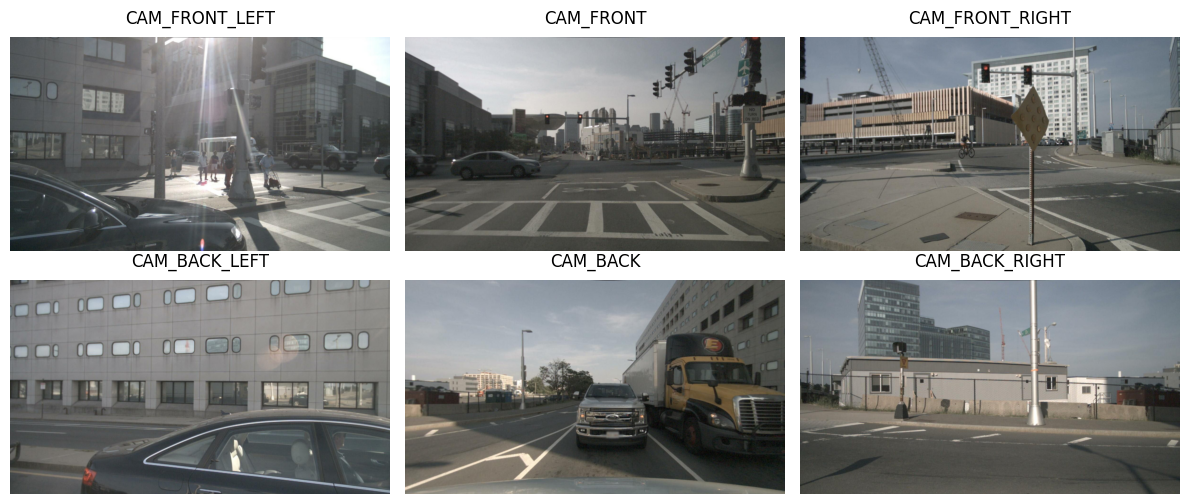

In [8]:
camera_names = ["CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_LEFT", "CAM_BACK", "CAM_BACK_RIGHT"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < len(pil_past_images):
        ax.imshow(pil_past_images[i])
        ax.set_title(camera_names[i], fontsize=12, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.7)
plt.show()

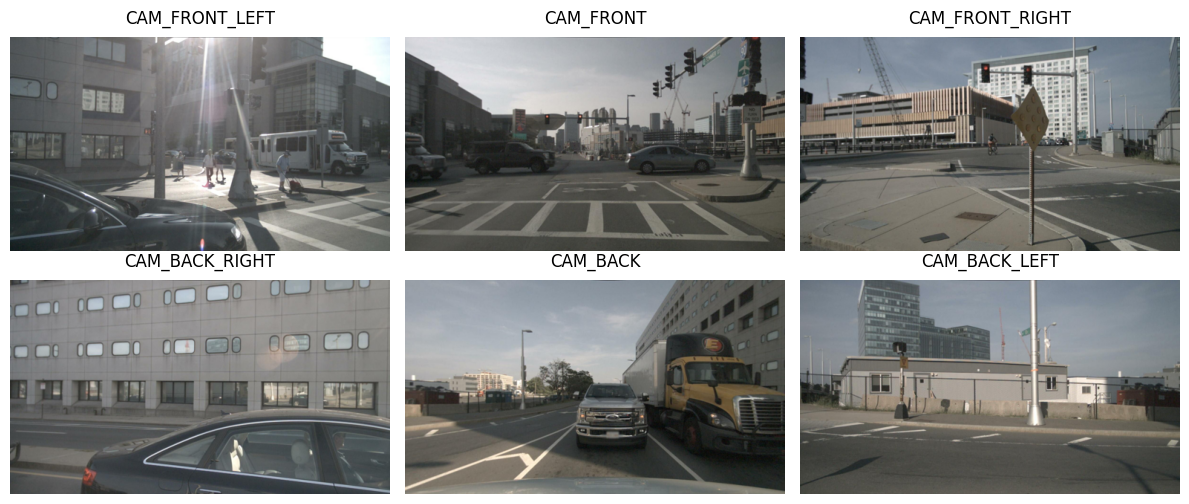

In [9]:
camera_names = ["CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT", "CAM_BACK", "CAM_BACK_LEFT"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < len(pil_images):
        ax.imshow(pil_images[i])
        ax.set_title(camera_names[i], fontsize=12, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.7)
plt.show()

In [10]:
print(wp_past)
print(vel_val, acc_val, yr_val)

(0.00, 0.00), (0.00, 0.00), (0.00, 0.00), (0.00, 0.00)
0.0 [0.16, -0.16] 0.0


# 

## Navigator (Large VLM)

In [11]:
# System and user prompts
system_prompt = (
    "You are an expert autonomous driving navigator. Your task is to analyze a 360-degree surround-view driving environment and provide concise, safety-oriented driving guidance.\n"
    "Guidelines:\n"
    "1. Coordinate System: The x-axis positive is forward, the y-axis positive is left.\n"
    "2. Attention Priority: Focus on 'Dynamic Hazards' (pedestrians, moving vehicles) and 'Traffic Regulators' (lights, signs, lane markings). Do not assume a red pedestrian signal implies vehicles must stop.\n"
    "3. Camera Emphasis: Focus primarily on information from the front cameras.\n"
    "4. Output Format: Start with a concise 'Perception' summary, followed by 'Action', and a brief 'Reasoning'.\n"
)
ego_status_prompt = (
    "Current Dynamics:\n"
    f"- Velocity: {vel_val:.2f} m/s.\n"
    f"- Yaw Rate: {yr_val:.2f} rad/s.\n"
    f"- Acceleration (Longitudinal x, Lateral y): ({acc_val[0]:.2f}, {acc_val[1]:.2f}) m/s^2.\n"
    f"- Past Trajectory (2Hz): {wp_past} m.\n\n"
    f"- High-level Command: {command}\n"
)
user_prompt = (
    f"Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.\n"
    f"1:FRONT_LEFT, 2:FRONT, 3:FRONT_RIGHT, 4:BACK_RIGHT. 5:BACK, 6:BACK_LEFT, \n\n"
    f"{ego_status_prompt}"
    "Task: Analyze the current situation and provide the safest next action with reasons."
)
# Full prompt
content = [{"type": "image"} for _ in range(len(pil_images))]
content.append({"type": "text", "text": user_prompt})

In [12]:
print(system_prompt)
print(user_prompt)

You are an expert autonomous driving navigator. Your task is to analyze a 360-degree surround-view driving environment and provide concise, safety-oriented driving guidance.
Guidelines:
1. Coordinate System: The x-axis positive is forward, the y-axis positive is left.
2. Attention Priority: Focus on 'Dynamic Hazards' (pedestrians, moving vehicles) and 'Traffic Regulators' (lights, signs, lane markings). Do not assume a red pedestrian signal implies vehicles must stop.
3. Camera Emphasis: Focus primarily on information from the front cameras.
4. Output Format: Start with a concise 'Perception' summary, followed by 'Action', and a brief 'Reasoning'.

Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.
1:FRONT_LEFT, 2:FRONT, 3:FRONT_RIGHT, 4:BACK_RIGHT. 5:BACK, 6:BACK_LEFT, 

Current Dynamics:
- Velocity: 0.00 m/s.
- Yaw Rate: 0.00 rad/s.
- Acceleration (Longitudinal x, Lateral y): (0.16, -0.16) m/s^2.
- Past Trajectory (2Hz): (0.00, 0.00), (0.00, 0.00), (0.00, 0.00), (0.00, 0.0

# Generate Reason

In [13]:
messgae, reason = scene_generate_v2(
    full_prompt=content,
    system=system_prompt,
    images=pil_images,
    processor=processor,
    model=navi_model,
    do_sample=True
)
print(reason)

Perception: The ego-vehicle is stationary at an intersection with a red traffic light. Pedestrians are visible crossing the street ahead, and a white shuttle bus is stopped at the curb to the right. The surrounding environment includes modern buildings and construction cranes in the distance.

Action: Remain stopped at the intersection. Do not proceed until the pedestrian crossing is complete and the traffic light turns green.

Reasoning: The ego-vehicle is legally required to stop at a red light. Pedestrians are actively crossing the intersection, and it is unsafe to proceed. The traffic light must change before any movement is permitted. The presence of a bus and construction in the background further emphasizes the need for caution.


In [14]:
reason_gemini = (
    "Perception: Critical Dynamics: The ego-vehicle is executing a low-speed left turn (Yaw Rate: 0.37 rad/s) at a wet, nighttime urban intersection.Hazards:CAM_FRONT: A pedestrian is actively crossing the road from right to left, directly in the ego-vehicle's intended path (crosswalk).CAM_FRONT: A white truck/van is navigating the intersection ahead, potentially obstructing the exit lane.CAM_BACK: A vehicle is following with headlights on; sudden braking could pose a rear-end risk.Environment: Road surface is wet, increasing stopping distances and glare."
    "Action: DECELERATE / YIELD Transition from positive acceleration ($0.31 m/s^2$) to braking. Prepare to bring the vehicle to a complete stop if the pedestrian does not clear the lane immediately. Maintain the current steering curvature to complete the turn only once the crosswalk is clear."
    "Reasoning: Despite the low current velocity ($2.66 m/s$), the vehicle is currently accelerating ($+0.31 m/s^2$ longitudinal) directly toward a vulnerable road user (VRU) in the crosswalk. Prioritizing the pedestrian is the absolute safety requirement. The wet road conditions necessitate earlier braking intervention to prevent skidding. The following vehicle in CAM_BACK requires the stop to be smooth, but does not override the need to yield to the pedestrian ahead."
)

# Driver (Small VLA)

In [15]:
reason = "Perception: The vehicle is stopped at an intersection at night. Front-facing cameras show a red traffic light and pedestrians crossing the road ahead. The surrounding environment is dimly lit, with tall buildings and streetlights visible. There is no immediate moving traffic in front, but the presence of pedestrians and a red light confirms that the vehicle must remain stopped.\n\nAction: Remain stopped at the intersection. Do not proceed until the traffic light turns green and it is safe to continue.\n\nReasoning: The high-level command is \u201cStop,\u201d and the current dynamics (velocity = 0.00 m/s) confirm the vehicle is stationary. The red traffic light and pedestrians crossing ahead indicate that proceeding would be unsafe and illegal. The vehicle must wait for the light to turn green and ensure all cross traffic and pedestrians have cleared the intersection before moving forward. The braking deceleration and lateral acceleration suggest the vehicle was recently slowing down, which aligns with the action to stay stopped.", "Perception: Vehicle is stopped at an intersection with red traffic light. Pedestrians are visible on the right sidewalk. A bus and other vehicles are ahead, stopped or moving slowly. The road ahead is clear in the forward direction but there are potential dynamic hazards from pedestrians and oncoming traffic.\n\nAction: Maintain stop. Do not proceed until the traffic light turns green and it is safe to proceed.\n\nReasoning: The ego-vehicle is stationary and must obey the red traffic light. Pedestrians are present nearby, and traffic ahead indicates ongoing flow; proceeding could result in collision or violation. Safety requires full stop and waiting for signal to change.", "Perception: Vehicle is stopped at an intersection with traffic lights. Front view shows a red light. Pedestrians are visible on the right sidewalk. Other vehicles are ahead in the intersection or approaching from other directions. Environment is urban, night-time, with streetlights and buildings.\n\nAction: Remain stationary and wait for the traffic light to turn green. Do not proceed until safe to do so.\n\nReasoning: The ego-vehicle is at a stop, indicated by zero velocity and deceleration/braking forces. The red traffic light mandates stopping. Proceeding while the light is red would be a violation of traffic rules and pose a safety hazard to pedestrians and other road users."

In [16]:
driver_system_prompt = (
    "You are an expert autonomous driving planning module (Driver). Your goal is to output a safe, smooth, and kinematically feasible future trajectory.\n"
    "Rules:\n"
    "1. Coordinate System: Current ego position is (0,0). X-axis positive is forward, Y-axis positive is left.\n"
    "2. Trajectory Timing: Output exactly 12 waypoints representing the next 6 seconds (sampled at 2Hz, 0.5s intervals).\n"
    "3. Kinematic Constraints: Ensure the gaps between waypoints are consistent with the current velocity and acceleration. Avoid sudden jumps or unrealistic lateral shifts.\n"
    "4. Safety Alignment: The trajectory must strictly follow the Navigator's safety analysis.\n"
    "5. Output Format: Only output the coordinates: (x1, y1), (x2, y2), ..., (x12, y12)."
)
driver_user_prompt = (
    "Predict the next 12 waypoints."
)
full_driver_prompt = (
    f"Navigator's Analysis and Instructions:\n{reason}\n\n"
    f"{ego_status_prompt}\n"
    f"{driver_user_prompt}"
)

# Generate Action

In [17]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = "checkpoints/qwen3-1.7b-dllm-sft-0202"
# ORIGINAL_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
# tokenizer = AutoTokenizer.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)

driver_processor = AutoTokenizer.from_pretrained(
    model_path,
    trust_remote_code=True
)

driver_model = AutoModelForCausalLM.from_pretrained(
    model_path,
    dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

driver_model.eval()

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048, padding_idx=151643)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (

In [18]:
messgae, output = reason_generate(
    user=full_driver_prompt,
    system=driver_system_prompt,
    # images=pil_images,
    processor=processor,
    model=driver_model,
    do_sample=True,
    max_new_tokens=128
)
print(output)

<think>

</think>

Future Waypoints: (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00), (0.00, -0.00).


In [19]:
print(messgae)

[{'role': 'system', 'content': "You are an expert autonomous driving planning module (Driver). Your goal is to output a safe, smooth, and kinematically feasible future trajectory.\nRules:\n1. Coordinate System: Current ego position is (0,0). X-axis positive is forward, Y-axis positive is left.\n2. Trajectory Timing: Output exactly 12 waypoints representing the next 6 seconds (sampled at 2Hz, 0.5s intervals).\n3. Kinematic Constraints: Ensure the gaps between waypoints are consistent with the current velocity and acceleration. Avoid sudden jumps or unrealistic lateral shifts.\n4. Safety Alignment: The trajectory must strictly follow the Navigator's safety analysis.\n5. Output Format: Only output the coordinates: (x1, y1), (x2, y2), ..., (x12, y12)."}, {'role': 'user', 'content': [{'type': 'text', 'text': "Navigator's Analysis and Instructions:\n('Perception: The vehicle is stopped at an intersection at night. Front-facing cameras show a red traffic light and pedestrians crossing the roa

In [20]:
print("VL Processor Template:\n", driver_processor.apply_chat_template(messgae, tokenize=False))

VL Processor Template:
 <|im_start|>system
You are an expert autonomous driving planning module (Driver). Your goal is to output a safe, smooth, and kinematically feasible future trajectory.
Rules:
1. Coordinate System: Current ego position is (0,0). X-axis positive is forward, Y-axis positive is left.
2. Trajectory Timing: Output exactly 12 waypoints representing the next 6 seconds (sampled at 2Hz, 0.5s intervals).
3. Kinematic Constraints: Ensure the gaps between waypoints are consistent with the current velocity and acceleration. Avoid sudden jumps or unrealistic lateral shifts.
4. Safety Alignment: The trajectory must strictly follow the Navigator's safety analysis.
5. Output Format: Only output the coordinates: (x1, y1), (x2, y2), ..., (x12, y12).<|im_end|>
<|im_start|>user
<|im_end|>



In [21]:
print("VL Processor Template:\n", processor.apply_chat_template(messgae, tokenize=False))

VL Processor Template:
 <|im_start|>system
You are an expert autonomous driving planning module (Driver). Your goal is to output a safe, smooth, and kinematically feasible future trajectory.
Rules:
1. Coordinate System: Current ego position is (0,0). X-axis positive is forward, Y-axis positive is left.
2. Trajectory Timing: Output exactly 12 waypoints representing the next 6 seconds (sampled at 2Hz, 0.5s intervals).
3. Kinematic Constraints: Ensure the gaps between waypoints are consistent with the current velocity and acceleration. Avoid sudden jumps or unrealistic lateral shifts.
4. Safety Alignment: The trajectory must strictly follow the Navigator's safety analysis.
5. Output Format: Only output the coordinates: (x1, y1), (x2, y2), ..., (x12, y12).<|im_end|>
<|im_start|>user
Navigator's Analysis and Instructions:
('Perception: The vehicle is stopped at an intersection at night. Front-facing cameras show a red traffic light and pedestrians crossing the road ahead. The surrounding en

In [22]:
def parse_waypoints(vlm_str):
    pattern = r"\((-?\d+\.?\d*),\s*(-?\d+\.?\d*)\)"
    matches = re.findall(pattern, vlm_str)
    
    if matches:
        waypoints = np.array(matches, dtype=float)
        return waypoints
    else:
        print("Warning: No waypoints found in VLM output!")
        return np.array([])

In [23]:
def plot_comparison(gt_pts, vlm_str):
    pred_pts = parse_waypoints(vlm_str)
    
    plt.figure(figsize=(10, 6))
    
    # Ground truth waypoints (Blue)
    plt.plot(gt_pts[:, 0], gt_pts[:, 1], 'bo-', label='Ground Truth', alpha=0.6)
    
    # Predicted waypoints (Red)
    if len(pred_pts) > 0:
        plt.plot(pred_pts[:, 0], pred_pts[:, 1], 'ro--', label='VLM Prediction')
    
    # Origin
    plt.plot(0, 0, 'gX', markersize=10, label='Current Pos')
    
    plt.xlabel('Forward Distance (x) [m]')
    plt.ylabel('Lateral Distance (y) [m]')
    plt.title('Trajectory Comparison: VLM vs Ground Truth')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Results

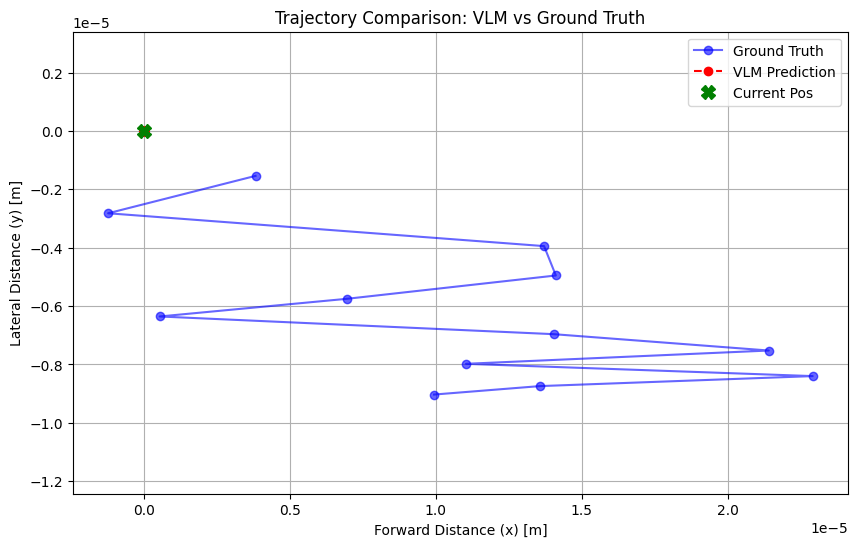

In [24]:
plot_comparison(future_waypoints, output)

# Record Data

In [25]:
wp_future = ", ".join([f"({pt[0]:.2f}, {pt[1]:.2f})" for pt in future_waypoints])

data_record = {
    "token": token,
    "wp_past": wp_past,
    "vel_val": vel_val,
    "acc_val": acc_val,
    "yr_val": yr_val,
    "reason": reason,
    "wp_future": wp_future
}

# with open('output.jsonl', 'a', encoding='utf-8') as f:
#     json.dump(data_record, f, ensure_ascii=False)
#     f.write('\n')

print("Record saved to output.jsonl")

Record saved to output.jsonl
